1. Importe o CSV de transações e mostre shape, columns e dtypes.

In [6]:
import pandas as pd

df_bank = pd.read_csv('bank_transactions_data_2.csv')

In [13]:
print('Shape')
print(df_bank.shape)

print('\nColumns')
print(df_bank.columns)

print('\nDtypes')
print(df_bank.dtypes)

Shape
(2512, 16)

Columns
Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='str')

Dtypes
TransactionID                  str
AccountID                      str
TransactionAmount          float64
TransactionDate                str
TransactionType                str
Location                       str
DeviceID                       str
IP Address                     str
MerchantID                     str
Channel                        str
CustomerAge                  int64
CustomerOccupation             str
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate        str
dtype: object


2. Use .head() e .describe() para uma primeira inspeção.

In [15]:
display(df_bank.head())

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [16]:
display(df_bank.describe())

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


3. Verifique valores nulos em cada coluna.

In [17]:
df_bank.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

4. Verifique linhas duplicadas e decida (justificando) se devem ser removidas.

In [18]:
df_bank.duplicated().sum()

np.int64(0)

5. Converta a coluna de data para datetime.


In [32]:
#TransactionDate,PreviousTransactionDate
df_bank['TransactionDate'] = pd.to_datetime(df_bank['TransactionDate'], format='%Y-%m-%d %H:%M:%S')
df_bank['PreviousTransactionDate'] = pd.to_datetime(df_bank['PreviousTransactionDate'], format='%Y-%m-%d %H:%M:%S')

In [33]:
df_bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   str           
 1   AccountID                2512 non-null   str           
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[us]
 4   TransactionType          2512 non-null   str           
 5   Location                 2512 non-null   str           
 6   DeviceID                 2512 non-null   str           
 7   IP Address               2512 non-null   str           
 8   MerchantID               2512 non-null   str           
 9   Channel                  2512 non-null   str           
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   str           
 12  TransactionDuration      2512 non-null   int6

6. Crie a coluna hora_transacao extraída da data/hora.


In [37]:
df_bank['hora_transacao'] = df_bank['TransactionDate'].dt.time

In [39]:
df_bank.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,hora_transacao
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,16:29:14
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,16:44:19
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,18:16:08
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,16:32:11
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,17:51:24


7. Filtre apenas transações Debit e calcule o valor médio.


In [45]:
df_bank.query("TransactionType == 'Debit'")['TransactionAmount'].mean()

np.float64(294.99125514403295)

8. Use groupby('canal') para o total transacionado por canal.


In [46]:
df_bank.groupby('Channel')['TransactionAmount'].sum()

Channel
ATM       256331.43
Branch    250183.00
Online    241041.14
Name: TransactionAmount, dtype: float64

9. Identifique as 5 contas (id_conta) com maior número de transações.


In [60]:
df_bank['AccountID'].value_counts().sort_values(ascending=False).head(5)

AccountID
AC00202    12
AC00460    12
AC00363    12
AC00362    12
AC00480    11
Name: count, dtype: int64

10. Como a base tem várias linhas por cliente, calcule a ocupacao_cliente mais frequente considerando *clientes únicos* (dica: drop_duplicates('id_conta') antes de contar) e compare com o resultado sem esse tratamento.


In [65]:
#df_bank.info() #CustomerOccupation

df_bank['CustomerOccupation'].value_counts().head(1)

CustomerOccupation
Student    657
Name: count, dtype: int64

11. Gere um histograma da distribuição dos valores de transação e comente o que ele sugere.


<Axes: ylabel='Frequency'>

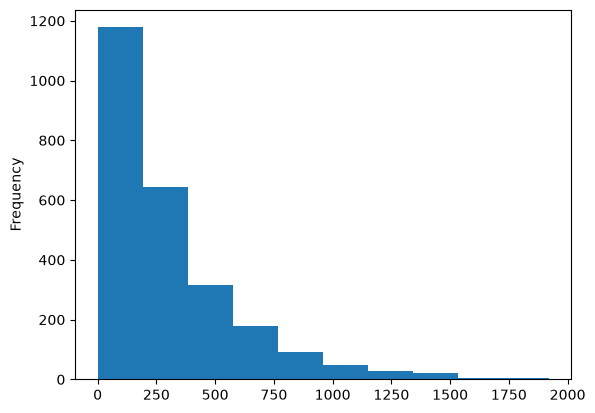

In [66]:
df_bank['TransactionAmount'].plot.hist()

12. Defina um critério simples de "fora do padrão" (ex: desvios-padrão da média) e conte quantas transações se encaixam.